<a href="https://colab.research.google.com/github/ronan-cunha/machine-learning-course/blob/main/Notebooks/aula_4_tratamento_dos_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
# Importar base de dados
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [18]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


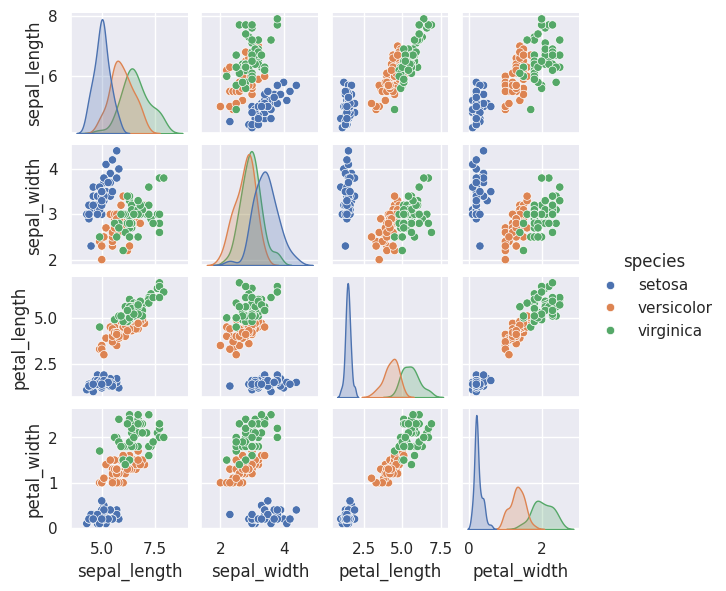

In [19]:
%matplotlib inline
import seaborn as sns; sns.set()
sns.pairplot(iris, hue='species', size=1.5);

In [30]:
# Gerar remover valores de forma aleatória da  base de dados
num_to_remove = int(len(iris) * 0.20) # número de linhas referente a 20% da amostra
random_indices = np.random.choice(iris.index, num_to_remove, replace=False) # indices aleatórios
iris_nan = iris[['sepal_length']].copy() # cópia da base de dados
iris_nan['sepal_length_nan'] = iris_nan['sepal_length'] # cópia da coluna
iris_nan.loc[random_indices, 'sepal_length_nan'] = np.nan # substitui os indices por NaN
iris_nan.head()

,sepal_length,sepal_length_nan
0,5.1,5.1
1,4.9,4.9
2,4.7,NaN
3,4.6,NaN
4,5.0,5.0


In [31]:
iris_nan.describe()

,sepal_length,sepal_length_nan
count,150.000000,120.000000
mean,5.843333,5.839167
std,0.828066,0.821998
min,4.300000,4.300000
25%,5.100000,5.100000
50%,5.800000,5.750000
75%,6.400000,6.400000
max,7.900000,7.900000


# Imputação de dados



In [32]:
# Imputação de dados
from sklearn.impute import SimpleImputer
imp = SimpleImputer(missing_values=np.nan, strategy='mean')
iris_nan['sepal_length_mean'] = imp.fit_transform(iris_nan[['sepal_length_nan']])
iris_nan.describe()

,sepal_length,sepal_length_nan,sepal_length_mean
count,150.000000,120.000000,150.000000
mean,5.843333,5.839167,5.839167
std,0.828066,0.821998,0.734600
min,4.300000,4.300000,4.300000
25%,5.100000,5.100000,5.400000
50%,5.800000,5.750000,5.839167
75%,6.400000,6.400000,6.200000
max,7.900000,7.900000,7.900000


In [33]:
imp = SimpleImputer(missing_values=np.nan, strategy='median')
iris_nan['sepal_length_med'] = imp.fit_transform(iris_nan[['sepal_length_nan']])
iris_nan.describe()

,sepal_length,sepal_length_nan,sepal_length_mean,sepal_length_med
count,150.000000,120.000000,150.000000,150.000000
mean,5.843333,5.839167,5.839167,5.821333
std,0.828066,0.821998,0.734600,0.735471
min,4.300000,4.300000,4.300000,4.300000
25%,5.100000,5.100000,5.400000,5.400000
50%,5.800000,5.750000,5.839167,5.750000
75%,6.400000,6.400000,6.200000,6.200000
max,7.900000,7.900000,7.900000,7.900000


In [36]:
# Criar uma base com as demais variaveis
iris_nan = iris.copy() # cópia da base de dados
iris_nan.loc[random_indices, 'sepal_length'] = np.nan # substitui os indices por NaN

random_indices = np.random.choice(iris.index, num_to_remove, replace=False)
iris_nan.loc[random_indices, 'petal_length'] = np.nan # substitui os indices por NaN

iris_nan.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,NaN,3.2,NaN,0.2,setosa
3,NaN,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [37]:
iris_nan = iris_nan.drop(columns = ['species'])

In [42]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imp = IterativeImputer(max_iter=10, random_state=0)
imp.fit(iris_nan)
iris_nan = imp.transform(iris_nan)
iris_nan = pd.DataFrame(iris_nan, columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
iris_nan.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.829045,3.057333,3.736700,1.199333
std,0.812767,0.435866,1.757651,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.558349,0.300000
50%,5.800000,3.000000,4.200000,1.300000
75%,6.376893,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [44]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# Transformação e padronização dos dados

In [46]:
from sklearn.preprocessing import StandardScaler
from scipy.special import expit # for logistic transformation

In [49]:
# Padronização
numerical_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
iris_numerical = iris[numerical_cols]
scaler = StandardScaler()
iris_standardized = pd.DataFrame(scaler.fit_transform(iris_numerical), columns=numerical_cols)
iris_standardized.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-4.736952e-16,-7.815970e-16,-4.263256e-16,-4.736952e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.433947e+00,-1.567576e+00,-1.447076e+00
25%,-9.006812e-01,-5.923730e-01,-1.226552e+00,-1.183812e+00
50%,-5.250608e-02,-1.319795e-01,3.364776e-01,1.325097e-01
75%,6.745011e-01,5.586108e-01,7.627583e-01,7.906707e-01
max,2.492019e+00,3.090775e+00,1.785832e+00,1.712096e+00


In [61]:
new_observation_df = pd.DataFrame({
    'sepal_length': [6],
    'sepal_width': [1],
    'petal_length': [3.0],
    'petal_width': [5.5]
})
new_observation_df

,sepal_length,sepal_width,petal_length,petal_width
0,6,1,3.0,5.5


In [62]:
scaler.transform(new_observation_df)

array([[ 0.5, -2. , -1. ,  4. ]])

In [63]:
# Transformação logistica - expit (sigmoid)
iris_logistic = pd.DataFrame(expit(iris_numerical), columns=numerical_cols)
iris_logistic.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,0.996096,0.951466,0.930155,0.743309
std,0.002914,0.019533,0.086548,0.137873
min,0.986613,0.880797,0.731059,0.524979
25%,0.993940,0.942676,0.832018,0.574443
50%,0.996982,0.952574,0.987242,0.785835
75%,0.998341,0.964429,0.993940,0.858149
max,0.999629,0.987872,0.998993,0.924142


In [64]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
iris_min_max = pd.DataFrame(min_max_scaler.fit_transform(iris_numerical), columns=numerical_cols)
iris_min_max.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,0.428704,0.440556,0.467458,0.458056
std,0.230018,0.181611,0.299203,0.317599
min,0.000000,0.000000,0.000000,0.000000
25%,0.222222,0.333333,0.101695,0.083333
50%,0.416667,0.416667,0.567797,0.500000
75%,0.583333,0.541667,0.694915,0.708333
max,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Transformação logistica - expit (sigmoid)
iris_logistic = pd.DataFrame(expit(iris_numerical), columns=numerical_cols)
iris_logistic.describe()

# Indetificação de outliers

In [65]:
# Método IQR
def outliers_detector_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

In [71]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [78]:
column_check = 'sepal_width'

outliers_sepal_length, lower_b, upper_b = outliers_detector_iqr(iris, column_check)

print(f"Outliers na coluna '{column_check}' usando o método IQR:")
print(f"Limite Inferior: {lower_b:.2f}")
print(f"Limite Superior: {upper_b:.2f}")
print(outliers_sepal_length[[column_check]])

Outliers na coluna 'sepal_width' usando o método IQR:
Limite Inferior: 2.05
Limite Superior: 4.05
    sepal_width
15          4.4
32          4.1
33          4.2
60          2.0


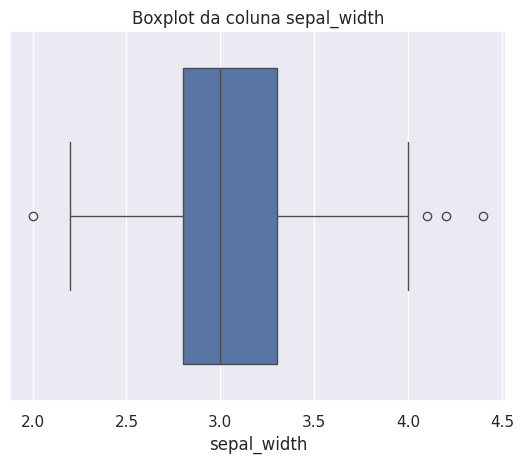

In [81]:
boxplot = sns.boxplot(data = iris, x=column_check)
plt.title(f'Boxplot da coluna {column_check}')
plt.show()

<Axes: xlabel='species', ylabel='sepal_width'>

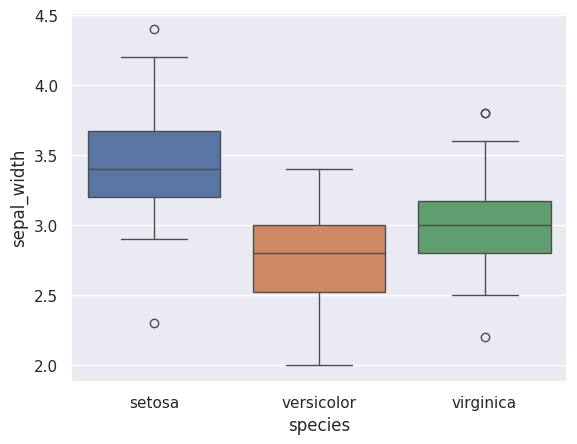

In [85]:
sns.boxplot(data = iris, x="species", y=column_check, hue="species")

# Atividade

## 1. Monte uma esteira de ponta a ponta que faça o seguinte tratamento:

  1. ETAPA 1: Imputação de Dados Ausentes com IterativeImputer
  2. ETAPA 2: Remoção de Outliers via IQR
  3. ETAPA 3: Padronização dos Dados
  4. ETAPA 4: Boxplot por variável

## 2. Monte a segunda esteira trocando a estratégia de imputação para SimpleImputer

## 3. Qual esteira gera a melhor base de dados? Discuta os resultados

## 4. DESAFIO: Usando como base a função outliers_detector_iqr, gere a função que identifica outliers através do intervalo de confiança.

In [124]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ----------------------------------------------------------
# Criação do Dataset Corrompido
# ----------------------------------------------------------
np.random.seed(42)
df_desafio = sns.load_dataset('iris')[
    ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
].copy()

# Inserindo NaNs e Outliers
mask_nan = np.random.rand(*df_desafio.shape) < 0.2
df_desafio[mask_nan] = np.nan
df_desafio.iloc[5, 0] = 9.0  # Outlier na sepal_length
df_desafio.iloc[20, 1] = 8.0  # Outlier na sepal_width

print('*** DATASET INICIAL ***')
df_desafio.describe()

*** DATASET INICIAL ***


,sepal_length,sepal_width,petal_length,petal_width
count,115.000000,119.000000,113.000000,118.000000
mean,5.895652,3.091597,3.679646,1.207627
std,0.875133,0.639595,1.768936,0.762940
min,4.300000,2.000000,1.100000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.200000,1.300000
75%,6.400000,3.400000,5.100000,1.800000
max,9.000000,8.000000,6.900000,2.500000
